# Defect identification

In order to analyse defect calculations, it is extremly useful to identify defects from lattice structures. In `defermi`, this feature is implementedin the `structure.defect_finder` function, which identifies defects by comparing the defect and pristine structures. Given the multitude of applications, the function's behaviour can be customized. The parameters are:

### Parameters

- `structure_defect` (`Structure`): Defect structure  

- `structure_bulk` (`Structure`): Bulk structure  

- `tol` (`float`): Tolerance for fractional coordinates comparison (default is `1e-3`)  

- `max_number_of_defects` (`int`): 
                                \
                                Impose a maximum number of defects to be found.\
                                If set, defects are ranked based on the coordinate distance between defect and bulk sites (descending order);\
                                the first `max_number_of_defects` are returned (as single defects or defect complexes) 

- `verbose` (`bool`): Print output#

Depending on the structures and if the defect structures are relaxed, it might be necessary to play around with the `tol` parameter.


In [1]:
from pymatgen.core import Structure

structure_bulk = Structure.from_dict({
  "@module": "pymatgen.core.structure", "@class": "Structure", "charge": 0,
  "lattice": {"matrix": [
                        [3.99037921, 0.0, 2.4434025634553223e-16],
                        [6.417019188399763e-16, 3.99037921, 2.4434025634553223e-16],
                        [0.0, 0.0, 4.10265539]], 
                        "pbc": [True, True, True],
                        "a": 3.99037921, "b": 3.99037921, "c": 4.10265539, 
                        "alpha": 90.0, "beta": 90.0, "gamma": 89.99999999999999, 
                        "volume": 65.32709969254628},
  "properties": {},
  "sites": [
    {"species": [{"element": "Ba","occu": 1}], "abc": [0.5, 0.5, 0.5825414600000001], "properties": {}, "label": "Ba2+", "xyz": [1.9951896050000002, 1.995189605, 2.38996686076747]},
    {"species": [{"element": "Ti","occu": 1}], "abc": [0.0, 0.0, 0.1000427], "properties": {}, "label": "Ti4+", "xyz": [0.0, 0.0, 0.41044072238515295]},
    {"species": [{"element": "O", "occu": 1}], "abc": [0.0, 0.5, 0.06422054], "properties": {}, "label": "O2-", "xyz": [3.2085095941998815e-16, 1.995189605, 0.26347474457971076]},
    {"species": [{"element": "O", "occu": 1}], "abc": [0.5, 0.0, 0.06422054], "properties": {}, "label": "O2-", "xyz": [1.995189605, 0.0, 0.26347474457971076]},
    {"species": [{"element": "O", "occu": 1}], "abc": [0.0, 0.0, 0.54897175], "properties": {}, "label": "O2-", "xyz": [0.0, 0.0, 2.252241909095232]}
  ]
})
structure_bulk.make_supercell(3);

In [2]:
from defermi.structure import defect_finder

structure_vac = structure_bulk.copy()
structure_vac.remove_sites([0])
structure_vac.perturb(distance=0.5)
structure_vac.composition

vacancies = defect_finder(
                    structure_defect=structure_vac,
                    structure_bulk=structure_bulk,
                    tol=0.05,
                    max_number_of_defects=None,
                    verbose=True)

Defect automatically identified for defective structure with composition Ba26 Ti27 O81: 
 Defect: type=Vacancy, species=Ba, site= [0.16666667 0.16666667 0.19418049]


In [3]:
structure_sub = structure_bulk.copy()
structure_sub.replace(0,species='Sr')
structure_sub.perturb(distance=0.5)
print(structure_sub.composition)

substitutions = defect_finder(
                    structure_defect=structure_sub,
                    structure_bulk=structure_bulk,
                    tol=0.01,
                    max_number_of_defects=None,
                    verbose=True)

Sr1 Ba26 Ti27 O81
Defect automatically identified for defective structure with composition Sr1 Ba26 Ti27 O81: 
 Defect: type=Substitution, species=Sr, site= [0.18663547 0.16326241 0.21537112]


In [4]:
structure_int = structure_bulk.copy()
structure_int.insert(-1,coords=[0.75,0.75,0.5],species='O')
structure_int.perturb(distance=0.5)
print(structure_int.composition)

interstitials = defect_finder(
                    structure_defect=structure_int,
                    structure_bulk=structure_bulk,
                    tol=0.002,  # lower tolerance to find this interstitial
                    max_number_of_defects=None,
                    verbose=True)

Ba27 Ti27 O82
Defect automatically identified for defective structure with composition Ba27 Ti27 O82: 
 Defect: type=Interstitial, species=O, site= [0.75784749 0.71858076 0.50939291]


In [5]:
structure_comp = structure_bulk.copy()
structure_comp.remove_sites([0])
structure_comp.replace(0,species='Sr')
structure_comp.insert(-1,coords=[0.75,0.75,0.5],species='O')
structure_comp.perturb(distance=0.5)
print(structure_comp.composition)

complexes = defect_finder(
                    structure_defect=structure_comp,
                    structure_bulk=structure_bulk,
                    tol=0.002,
                    max_number_of_defects=None,
                    verbose=True)

# setting max_number_of_defects returns a limited number of defects, ranked in descending order based on distance to bulk site
defects = defect_finder(
                    structure_defect=structure_comp,
                    structure_bulk=structure_bulk,
                    tol=0.002,
                    max_number_of_defects=1,
                    verbose=True)

Sr1 Ba25 Ti27 O82
Defect automatically identified for defective structure with composition Sr1 Ba25 Ti27 O82: 
 DefectComplex: [ Defect: type=Substitution, species=Sr, site= [0.17518187 0.16400641 0.55764191], Defect: type=Interstitial, species=O, site= [0.74984563 0.74989248 0.49988713], Defect: type=Vacancy, species=Ba, site= [0.16666667 0.16666667 0.19418049], ] 
Defect automatically identified for defective structure with composition Sr1 Ba25 Ti27 O82: 
 Defect: type=Interstitial, species=O, site= [0.74984563 0.74989248 0.49988713]


## Visualization

`defermi` provides functions to generate structures helpful for visualization, with dummy atoms as vacancies and displacement vectors.


Defect: type=Vacancy, species=Ba, site= [0.16666667 0.16666667 0.19418049]
Cs1 Ba26 Ti27 O81


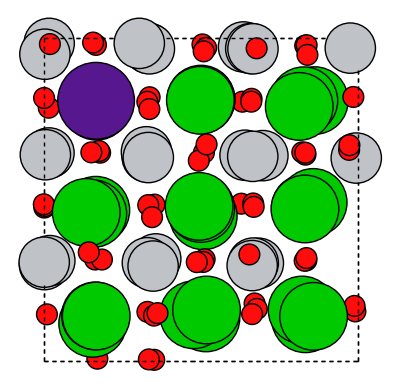

In [21]:
from defermi.structure import create_def_structure_for_visualization
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt

print(vacancies)
structure = create_def_structure_for_visualization(
                                    structure_defect=structure_vac,
                                    structure_bulk=structure_bulk,
                                    defects=vacancies)

print(structure.composition) # Cs as dummy atom to represent Ba vacancy
ax = plot_atoms(structure.to_ase_atoms(),rotation=('90x, 90y, 0z'),radii=0.6)
ax.set_axis_off()

if `defects` is not provided, `defect_finder` is called. 

In [22]:
structure = create_def_structure_for_visualization(
                                    structure_defect=structure_vac,
                                    structure_bulk=structure_bulk,
                                    sort_to_bulk=True,
                                    tol=0.02)
structure.composition

Composition('Cs1 Ba26 Ti27 O81')

It is often useful to visualize the atomic displacements relative to the pristine structure after relaxing atomic positions. Save the structure with dummy atoms including the displacements vector as `extxyz` file with the `write_extxyz_for_visualization` function. You can visualize these structures with visualization software like [OVITO](https://www.ovito.org/).

In [2]:
from defermi.structure import write_extxyz_for_visualization

# write_extxyz_for_visualization(file='vacancy.extxyz'
#                                 structure_defect=structure_vac,
#                                 structure_bulk=structure_bulk,
#                                 defects=vacancies)